# Simple Linear Regression Modeling

This notebook introduces simple linear regression, including:
- Understanding response vs explanatory variables  
- Visualizing relationships between variables  
- Fitting regression models using seaborn and statsmodels  
- Interpreting intercept and slope  
- Working with categorical variables in regression  

## Objective
To understand how simple linear regression works and how to interpret model coefficients using Python.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

In [3]:
np.random.seed(42)

df = pd.DataFrame({
    "x": np.random.randint(1, 20, 100),
    "y": 3 + 2 * np.random.randint(1, 20, 100) + np.random.normal(0, 5, 100),
    "category": np.random.choice(["A", "B", "C"], 100)
})

## Understanding Variables
- Response variable (y): what we predict  
- Explanatory variable (x): what we use to predict  

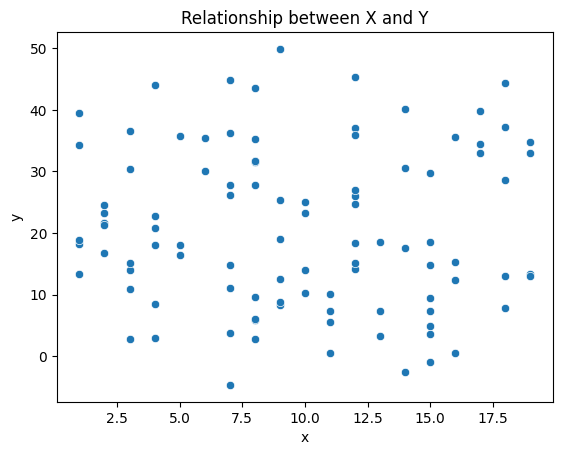

In [4]:
sns.scatterplot(x="x", y="y", data=df)
plt.title("Relationship between X and Y")
plt.show()

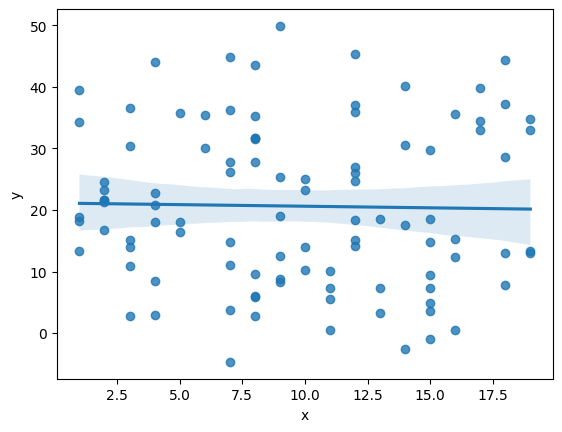

In [5]:
sns.regplot(x="x", y="y", data=df)
plt.show()

In [8]:
model = ols("y ~ x", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.04367
Date:                Sun, 19 Apr 2026   Prob (F-statistic):              0.835
Time:                        04:03:42   Log-Likelihood:                -397.60
No. Observations:                 100   AIC:                             799.2
Df Residuals:                      98   BIC:                             804.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.1250      2.716      7.778      0.0

## Interpretation
- Intercept: predicted value when x = 0  
- Slope: change in y for each unit increase in x  

In [9]:
print(model.params)

Intercept    21.125006
x            -0.051665
dtype: float64


## Categorical Variables in Regression
We can also use categories instead of numeric variables.

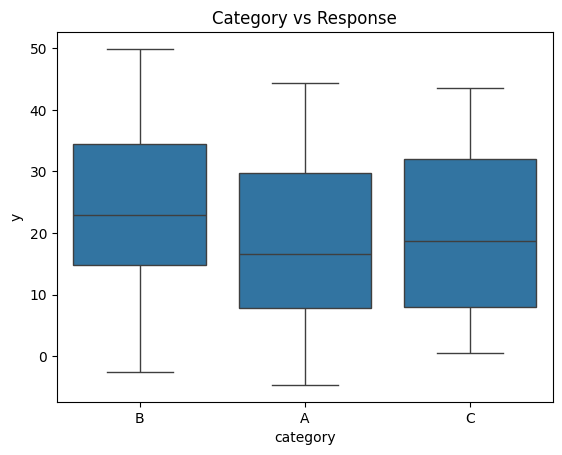

In [10]:
sns.boxplot(x="category", y="y", data=df)
plt.title("Category vs Response")
plt.show()

In [11]:
df.groupby("category")["y"].mean()

,y
category,
A,18.243671
B,23.804608
C,19.369219


In [12]:
cat_model = ols("y ~ category", data=df).fit()
print(cat_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.932
Date:                Sun, 19 Apr 2026   Prob (F-statistic):              0.150
Time:                        04:05:52   Log-Likelihood:                -395.67
No. Observations:                 100   AIC:                             797.3
Df Residuals:                      97   BIC:                             805.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        18.2437      2.084      8.755

In [13]:
print(cat_model.params)

Intercept        18.243671
category[T.B]     5.560937
category[T.C]     1.125548
dtype: float64


## Conclusion
- Linear regression models relationships between variables  
- Slope shows strength and direction of relationship  
- Categorical variables can also be used in regression  